# FitzHugh-Nagumo Model

## Single input pulse

In [31]:
import numpy as np
from matplotlib import pyplot as plt

In [32]:
n_iter = 250
t_max = 25
t_range, dt = np.linspace(0, t_max, n_iter, retstep=True)

v = -1.2
w = -0.625

input_current = np.zeros(n_iter, dtype=np.float64)
input_current[0:49] = 0.3

v_hist = np.empty(n_iter, dtype=np.float64)
w_hist = np.empty(n_iter, dtype=np.float64)

$$
    dv = v - \frac{v^3}{3} - w + I
$$

In [33]:
def calc_dv(v, w, I) -> float:
    return v - (v**3 / 3) - w + I

$$
w = 0.08(v - 0.8w + 0.7)
$$

In [34]:
def calc_dw(v, w) -> float:
    return 0.08 * (v - 0.8 * w + 0.7)

In [35]:
for i in range(n_iter):
    I = input_current[i]

    dv = calc_dv(v, w, I)
    dw = calc_dw(v, w)

    v += dv * dt
    w += dw * dt

    v_hist[i] = v
    w_hist[i] = w

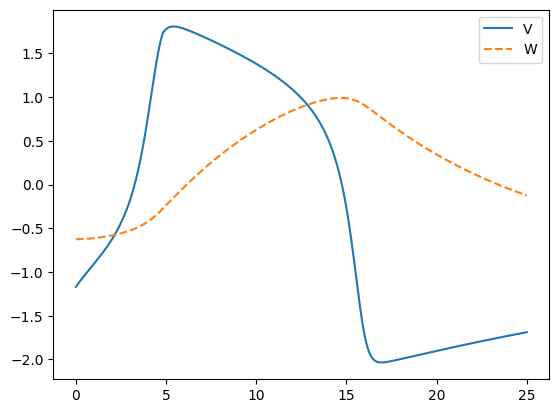

In [36]:
plt.figure(1)
plt.plot(t_range, v_hist, "-", label="V")
plt.plot(t_range, w_hist, "--", label="W")
plt.legend()
plt.show()

## Sustained input current - continuous oscillations

In [37]:
n_iter = 1000
dt = 0.1
t_range, dt = np.linspace(0, 100, 1000, retstep=True)

v = np.empty(n_iter)
w = np.empty(n_iter)
I = 0.5

v[0] = -0.625
w[0] = -1.2

In [38]:
for i in range(n_iter - 1):
    dv = calc_dv(v[i], w[i], I)
    dw = calc_dw(v[i], w[i])

    v[i + 1] = v[i] + dv * dt
    w[i + 1] = w[i] + dw * dt

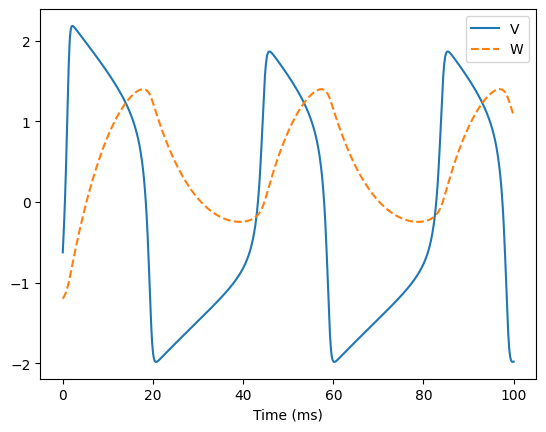

In [39]:
plt.figure(2)
plt.plot(t_range, v, "-", label="V")
plt.plot(t_range, w, "--", label="W")
plt.xlabel("Time (ms)")
plt.legend()
plt.show()